# Aim 3
Tara Cornwell June 2024

Adapted from Darici and Kuo

### First, let's simulate unperturbed and perturbed step conditions.

In [1]:
# Import necessary packages
using DynLoco_TC, Plots; 

# Create structure for "walk"
wstar = findgait(WalkRW2l(α=0.41,safety=true), target=:speed=>0.44, varying=:P)

# Set number of steps: pre, pert, recovery
nsteps = 4

# Setup perturbation vector
perts = [1 1 1.5 1]

# Run optimization that minimizes push-off work
nominal_result = optwalk_TC(wstar, nsteps, boundaryvels=(wstar.vm, wstar.vm), boundarywork=false)
pert_result = optwalk_TC(wstar, nsteps, boundaryvels=(wstar.vm, wstar.vm), boundarywork=false, perts=perts)

# Apply naive control to perturbation condition
naive_result = multistep(wstar; Ps=nominal_result.steps.P,boundaryvels=(wstar.vm, wstar.vm), perts=perts)

# Print results
println("Without pert, total work cost = ", nominal_result.workcost)
println("With pert considered in opt, total work cost = ", pert_result.workcost)
println("With pert not considered in opt, total work cost = ", naive_result.workcost)

Without pert, total work cost = 0.12235240002689825
With pert considered in opt, total work cost = 0.08708766943450995
With pert not considered in opt, total work cost = 0.12235240002689825


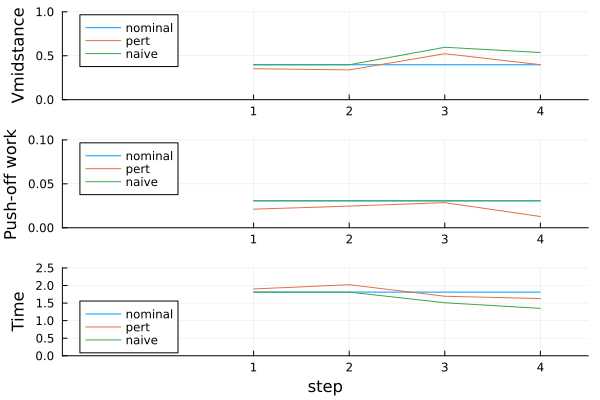

In [12]:
# Plots
l = @layout [a; b; c]

p1 = plot(nominal_result.steps.vm, label="nominal")
plot!(pert_result.steps.vm, ylabel="Vmidstance", label="pert")
plot!(naive_result.steps.vm, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(nominal_result.steps.Pwork, ylabel="Push-off work", label="nominal")
plot!(pert_result.steps.Pwork, label="pert")
plot!(naive_result.steps.Pwork, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(nominal_result.steps.tf, xlabel="step", ylabel="Time", label="nominal")
plot!(pert_result.steps.tf, label="pert")
plot!(naive_result.steps.tf, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2.5), xticks = 1:1:nsteps, yticks = 0:0.5:2.5)

plot(p1, p2, p3, layout = l)

### Now let's try using the MPC controller.

In [3]:
# Run optimization that minimizes push-off work

nhorizon=1
mpc_result1 = mpcstep(wstar, nsteps, nhorizon, perts=perts)

nhorizon=2
mpc_result2 = mpcstep(wstar, nsteps, nhorizon, perts=perts)

nhorizon=3
mpc_result3 = mpcstep(wstar, nsteps, nhorizon, perts=perts)

nhorizon=nsteps
mpc_result_full = mpcstep(wstar, nsteps, nhorizon, perts=perts)

# Print results
println("With horizon = 1, PO work cost = ", mpc_result1.workcost)
println("With horizon = 2, PO work cost = ", mpc_result2.workcost)
println("With horizon = 3, PO work cost = ", mpc_result3.workcost)
println("With full horizon, PO work cost = ", mpc_result_full.workcost)

With horizon = 1, PO work cost = 0.10051896978015659
With horizon = 2, PO work cost = 0.08554765841564764
With horizon = 3, PO work cost = 0.08091783261763463
With full horizon, PO work cost = 0.08016058013221367


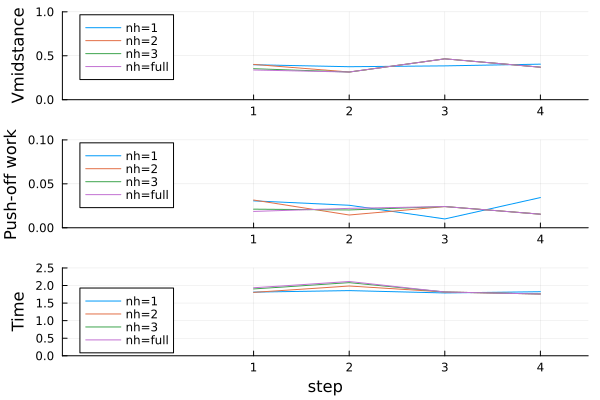

In [13]:
# Plots
l = @layout [a; b; c]

p1 = plot(mpc_result1.steps.vm, label="nh=1")
plot!(mpc_result2.steps.vm, label="nh=2")
plot!(mpc_result3.steps.vm, label="nh=3")
plot!(mpc_result_full.steps.vm, ylabel="Vmidstance", label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mpc_result1.steps.Pwork, ylabel="Push-off work", label="nh=1")
plot!(mpc_result2.steps.Pwork, label="nh=2")
plot!(mpc_result3.steps.Pwork, label="nh=3")
plot!(mpc_result_full.steps.Pwork, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(mpc_result1.steps.tf, xlabel="step", ylabel="Time", label="nh=1")
plot!(mpc_result2.steps.tf, label="nh=2")
plot!(mpc_result3.steps.tf, label="nh=3")
plot!(mpc_result_full.steps.tf, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2.5), xticks = 1:1:nsteps, yticks = 0:0.5:2.5)

plot(p1, p2, p3, layout = l)

### Test different weights on objective function

In [5]:
nhorizon=2

result_0 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=0)
result_1 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=1)
result_5 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=0.5)

# Print results
println("Min. work alone, work cost = ", result_0.workcost)
println("Min. changes in step time alone, work cost = ", result_1.workcost)
println("Min. both work and changes to step time equally, work cost = ", result_5.workcost)


Min. work alone, work cost = 0.08554765841564764
Min. changes in step time alone, work cost = 0.10362584114645962
Min. both work and changes to step time equally, work cost = 0.09399037819981526


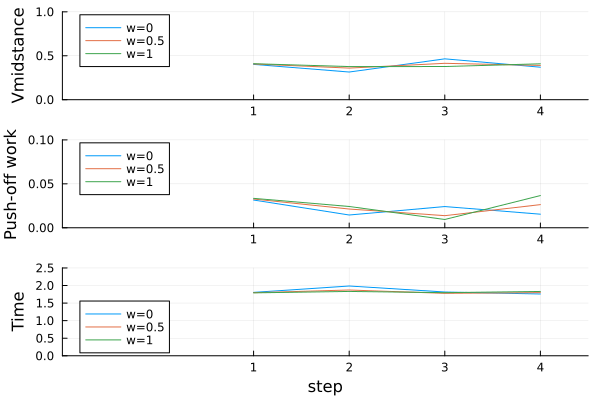

In [15]:
# Plots
l = @layout [a; b; c]

p1 = plot(result_0.steps.vm, ylabel="Vmidstance", label="w=0")
plot!(result_5.steps.vm, label="w=0.5")
plot!(result_1.steps.vm, label="w=1")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(result_0.steps.Pwork, ylabel="Push-off work", label="w=0")
plot!(result_5.steps.Pwork, label="w=0.5")
plot!(result_1.steps.Pwork, label="w=1")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(result_0.steps.tf, xlabel="step", ylabel="Time", label="w=0")
plot!(result_5.steps.tf, label="w=0.5")
plot!(result_1.steps.tf, label="w=1")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2.5), xticks = 1:1:nsteps, yticks = 0:0.5:2.5)

plot(p1, p2, p3, layout = l)

In [18]:
using CSV

path = "M.csv"
df = CSV.read(path, DataFrame)

LoadError: UndefVarError: DataFrame not defined